# Perceptron - TD4


## Objectifs du TP :

A grands traits, voici les objectifs du TP (ensuite, suivez les questions, c'est assez guidé en fait):
- On va tenter de trouver un plan (droite) qui sépare 2 nuages de points, en 2D. Cela aide a débugger le code car on peut visualiser l'évolution du plan qui correspond au modèle, au fur et à mesure des itérations de la descente de gradient.
- **Implémenter l'algorithme du peceptron**  qui correspond à ce modèle de classification binaire par un hyperplan. 
- Y ajouter du suivi: mesurer et stocker des métriques de performance (ici typiquement la fonction cout (Loss) et le taux d'erreur) pour l'ensemble d'entrainement et l'ensemble de validation. Puis les tracer
- Si le temps le permet, utiliser votre algorithme sur mini-MNIST, un jeu de données qui représente des images de chiffres tracés à la main et ensuite numérisés. On se placera dans le cas binaire, donc on classifiera par exemple seulement les 0 et les 1. Si votre code est bien écrit, le passage du nuage de points en 2D a des images en 8x8 pixels ne pose aucun problème (évidemment on ne peut plus visualiser le plan de séparation car il y a trop de dimensions)

Si vous connaissez déjà bien Python, ce TP est l'occasion d'apprendre a vectoriser les boucles avec numpy (c.a.d. utiliser des opération sur des `np.array` plutot que des boucles Python).

Si vous débutez en Python, ce TP sera l'occasion de vous familiariser avec ce langage (qu'il faudra aussi travailler chez vous). 

## 0. Création de données en 2D et visualisation de la droite caractérisée par `w`

#### Remarque :
Dans cette partie vous n'avez rien a coder, juste a executer les cellules et inspecter un peu ce que fait le code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap


In [2]:
def make_blobs(N):
    # data set 3
    N1=N//4
    N2=N-N1
    D=2
    np.random.seed(42)

    # parameters for the 1st blob of points
    mu1=(0.3,0.3)
    sigma1=((1, 0.3))
    X1 = np.random.normal( mu1, sigma1,(N1,D))

    # parameters for the 2nd blob of points
    mu2=(-2,-2)
    sigma2=((2, 0.5))
    X2 = np.random.normal( mu2, sigma2,(N2,D))

    # the two blobs are merged, and labels  +1/-1  are assigned
    Xraw = np.concatenate( (X1, X2) )
    Y = np.concatenate( (np.ones(N1), -np.ones(N2)) ) # .reshape(N,1)
    X = Xraw.copy() # then X will be the extended vector, with the ones added

    X =  np.hstack((np.ones((N,1)), X))  # extended vector

    return X,Y


def display(X, Y, wInit, iteration):

    def norme(wprime):
        return np.linalg.norm(wprime)
    
    assert wInit.shape[0]==3, "cette fonction affiche l'hyperplan séparateur, a condition que ce soit une droite, pas un plan de plus grande dimension" 
    w=wInit.copy()
    w0= w[0] # c'est la partie qui caractérise la distance à l'origine, qui détermine l'ordonnée à l'origine (mais ce n'est pas égal à ça)
    ## on normalise les composantes du vrai vecteur w
    wprime = w[1:] # /(w[1]**2+w[2]**2)**0.5
    if norme(wprime) > 0 :
        u_w = (wprime/norme(wprime)) # vecteur unitaire donnant la direction
        distance_origine_droite = -w0/norme(wprime)
        projete_de_Origine_sur_droite = u_w * distance_origine_droite

        vecteur_Orthogonal_A_La_Droite = np.array([wprime[1],-wprime[0]])
        extremite1 = projete_de_Origine_sur_droite + vecteur_Orthogonal_A_La_Droite*10
        extremite2 = projete_de_Origine_sur_droite - vecteur_Orthogonal_A_La_Droite*10
        extremites_abscisses = np.array([extremite1[0], extremite2[0]])
        extremites_ordonnees = np.array([extremite1[1], extremite2[1]])


    plt.figure(1)
    Class1 = X[Y==-1,1:] # points of class "-1"
    Class2 = X[Y== 1,1:] # points of class "+1"
    plt.plot(Class1[:,0], Class1[:,1], 'r+') # points of class "-1"
    plt.plot(Class2[:,0], Class2[:,1], 'bx') # points of class "+1"
    cmap = cm.jet
    colorGradient=cmap(np.linspace(0.0,1.0,12))
    if norme(wprime) > 0 :
        plt.plot(extremites_abscisses, extremites_ordonnees,  color=colorGradient[iteration%(len(colorGradient))])
        
    

In [3]:
N=100
X, Y = make_blobs(100)


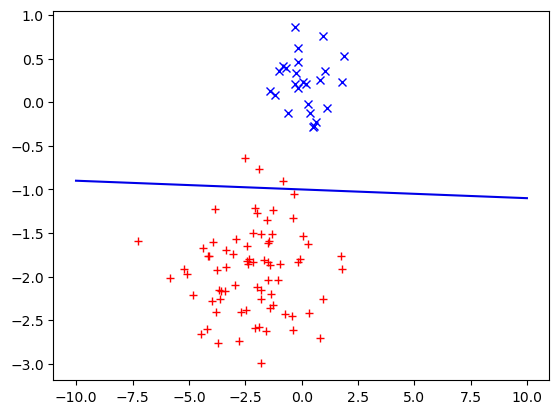

In [4]:
w0 = np.array([1,0.01,1])  ## w initial fixé, juste pour afficher une droite
display(X,Y, w0, 1)


### Remarque : 
Les données sont déjà augmentées :  (on a mis "le 1")

Dans la fonction make_blobs, cela correspond à la ligne :

`X =  np.hstack((np.ones((N,1)), X))`

In [5]:
X[:4] 

array([[1.        , 0.79671415, 0.25852071],
       [1.        , 0.94768854, 0.75690896],
       [1.        , 0.06584663, 0.22975891],
       [1.        , 1.87921282, 0.53023042]])

## 1. Initialisation des poids

- faites un choix pour la valeur initiale de `w`, c.a.d donnez une valeur à $\vec w_0=$ `w0`. Idéalement, en ML, on les génère au hasard, par exemple avec une disitribution Gaussienne, **centrée en 0**, d'écart type $1/\sqrt{D}$ (si votre écart type est de 1, ça va aussi). Dans le cas du perceptron, une simple initialisation avec tous les poids à $0$ a aussi du sens
- choisissez des valeurs pour les hyper-parametres `eta`, `MaxIter`

In [6]:
np.random.seed(48)

In [7]:
## TODO: créer une fonction qui inialise les poids
## (soit aléatoirement, soit de façon pré-fixée)
## init_type = 'random' ou 'zeros'
def initializeWeights(X, init_type = 'random'):  # on ne regarde X que pour produire un w de la bonne dimension D.
    '''
    Input :
    X : Les données, elles nous servent seulement à déterminer la dimension D (et donc la taille de w)
    init_type : Si init_type prend la valeur random, on initialise w aléatoirement, sinon on l'initialise avec le vecteur nul (ne contenant que des zéros)
    Output :
    w : Le vecteur de poids initialisé.
    '''
    D= X.shape[1] ## TODO: quelle est la dimension des données ?
    if init_type == 'random':
        w = np.random.random((D))
    else:
        w = np.zeros((D))
    return w


[0.01749027 0.89157327 0.28486117]


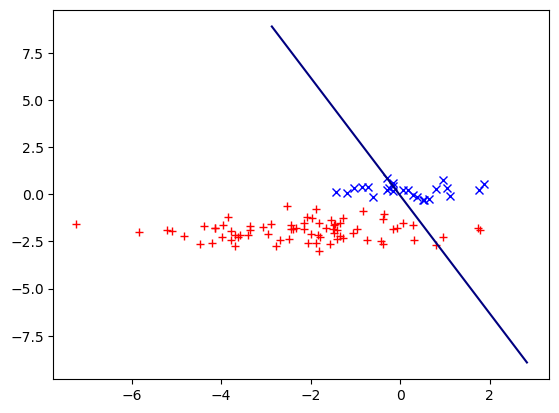

In [8]:
######### initialization of the separating vector ######
w0 = initializeWeights(X,"random")  ## w initial
print(w0)
display(X,Y, w0, 0)

## 2. Implémentation de l'algorithme du perceptron

### 2.1 Implémentations minimales

#### Remarque :
Cela revient juste à écrire au choix soit le code trouvé dans le CM3 (version *online*), soit le code trouvé dans le TD3 (version *fullbatch*). 

Vous pouvez le coder en suivant :

- soit la version naïve, avec des boucles, 
- soit la version plus numpy-esque (qui est moins triviale à lire et à coder, mais environ 100x plus rapide a éxécuter).

In [9]:
## TODO: remplir cette fonction (au moins, sans les affichages
## mais de sorte que le résultat soit correct)
def perceptron_version_minimale(X,Y,eta, w0, maxIter=20):
    error = 1
    iter = 0
    w = w0
    while (error > 0 and iter < maxIter):
        iter+=1
        mask = X@w*Y < 0
        w += eta*(1/N)*Y[mask]@X[mask]
        error = mask.sum()
    return w

In [10]:
### hyper-parameters ###
MAXITER = 85
eta = 0.8
## on lance le calcul
w =  perceptron_version_minimale(X,Y,eta, w0, MAXITER)

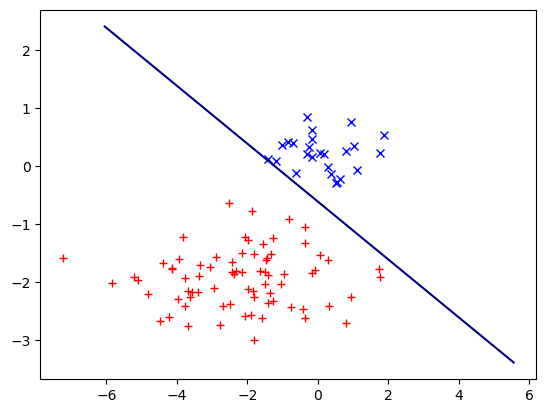

In [11]:
## voyons si ça a bien marché, visuellement:
display(X,Y, w, 0)

### 2.2 Implémentation avec suivi 

#### Quand votre code "minimaliste" converge, ou bien même si il compile sans converger, et que vous voulez comprendre pourquoi :

Faites une version plus avancée `perceptron_version_decoree`, dans laquelle vous réalisez:
- un découpage (*split*) des données (train/validation) à partir de vos données d'entrainement. Vous pouvez utiliser `sklearn.model_selection.train_val_split`
- un calcul du taux d'erreur (sur l'ensemble d'entrainement)
- un calcul du taux d'erreur (sur l'ensemble de validation)
- un calcul de la fonction cout (sur l'ensemble d'entrainement)
- un calcul de la fonction cout (sur l'ensemble de validation)
- un affichage de l'hyperplan de séparation, à l'aide de la fonction display, qui est fournie (option controlée par le paramètre booleen `plotting`)

In [12]:
plotting = True
verbose = True

In [13]:
## TODO: remplir cette fonction 
from sklearn.model_selection import train_test_split

def perceptron_version_decoree(X,Y,eta, w0, maxIter=20, plot=None, verbose=None, Loss=None):
    iter = 0
    w = w0
    N = X.shape[0]
    N_train = int(N*0.8)

    X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,     # because you want 40% train / 60% val
    shuffle=True,
    random_state=42    # for reproducibility
)
    lerror_train = []
    lerror_val = []
    lloss_train = []
    lloss_val = []
    mask_train = (X_train@w*Y_train <=0)
    mask_val = (X_val@w*Y_val <=0)
    error_train = (mask_train).sum()/N_train
    error_val = (mask_val).sum()/(N-N_train)
    loss_train = -(X_train[mask_train]@w*Y_train[mask_train]).sum()/N_train
    loss_val = -(X_val[mask_val]@w*Y_val[mask_val]).sum()/(N-N_train)
    lerror_train.append(error_train)
    lerror_val.append(error_val)
    lloss_train.append(loss_train)
    lloss_val.append(loss_val)
    print(error_train)
    display(X, Y, w, iter)
    while (error_train > 0 and iter < maxIter):
        iter+=1
        mask = X@w*Y <= 0
        w += eta*(1/N)*Y[mask]@X[mask]

        mask_train = (X_train@w*Y_train <=0)
        mask_val = (X_val@w*Y_val <=0)
        error_train = mask_train.sum()/N_train
        error_val = mask_val.sum()/(N-N_train)
        loss_train = -(X_train[mask_train]@w*Y_train[mask_train]).sum()/N_train
        loss_val = -(X_val[mask_val]@w*Y_val[mask_val]).sum()/(N-N_train)
        lerror_train.append(error_train)
        lerror_val.append(error_val)
        lloss_train.append(loss_train)
        lloss_val.append(loss_val)
        display(X, Y, w, iter)
    return w, lerror_train, lerror_val, lloss_train, lloss_val

0.1


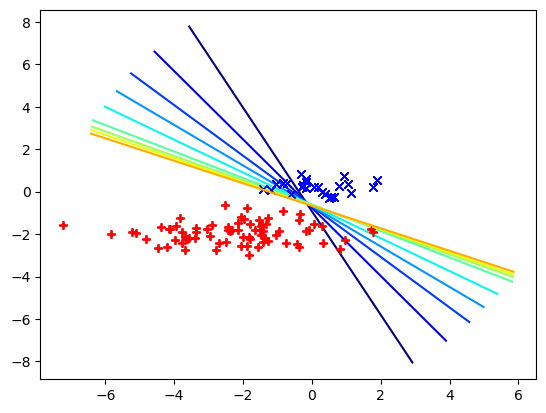

In [14]:
### hyper-parameters ###
MAXITER=85
eta = 1
## on lance le calcul
w0  = initializeWeights(X,"random")  ## w initial
w, err_train, err_val, loss_train, loss_val =  perceptron_version_decoree(X,Y,eta, w0, MAXITER, plotting, verbose)

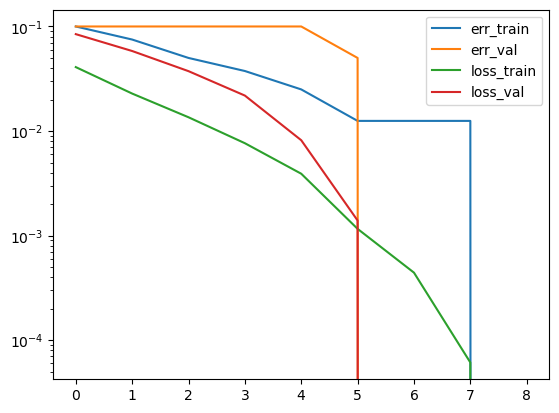

In [15]:
plt.plot(err_train, label = 'err_train')
plt.plot(err_val, label = 'err_val')
plt.plot(loss_train, label = 'loss_train')
plt.plot(loss_val, label = 'loss_val')
plt.semilogy()
plt.legend()

## 3. Application sur données réelles

### 3.1 Application sur mini-MNIST

#### On teste sur des "vraies" données (en fait, c'est encore un très petit jeu de données)

In [16]:
import sklearn.datasets
import sklearn.model_selection

#### Load_digits (mini-MNIST, en taille 8x8, avec seulement ~2000 exemples)

Remarque: Le MNIST complet en contient 70000, chacun de taille 28x28. Allez voir https://gitlab.inria.fr/flandes/data-for-teaching/-/blob/master/import-mnist70-numpy-npz.py si vous voulez charger mon fichier https://gitlab.inria.fr/flandes/data-for-teaching/-/blob/master/mnist70.npz

In [17]:

X, Y = sklearn.datasets.load_digits(n_class=2, return_X_y=True)

## on fait immédiatement l'astuce du 1 (augmentation de toutes les données par ajout d'une colonne de 1)
N = X.shape[0]
X =  np.hstack((np.ones((N,1)), X))  # extended vector

## on encode le label "Ground Truth" (vrai) dans les valeurs {-1,1} plutot que {0,1}
Y = ?? TODO

## on coupe et on réserve 20% des data pour le test final 
X, X_test, Y, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)

SyntaxError: invalid syntax (4071148939.py, line 8)

In [ ]:
## la premiere image est un zero:
plt.imshow(X[0,1:].reshape(8, 8), cmap=plt.cm.binary)

In [ ]:
## la 45ème image est un 1:
plt.imshow(X[44,1:].reshape(8, 8), cmap=plt.cm.binary)

In [ ]:
### hyper-parameters ###
MAXITER=200
eta = 0.001
## on lance le calcul
plotting=False
verbose=False

## on initialise w avec la bonne dimension (ceci pourrait/devrait etre fait dans la fonction de fit, en fait)
np.random.seed(12)
w0 = mes_fonctions.initializeWeights(X, "random")

w, err_train, err_val, loss_train, loss_val =  mes_fonctions.perceptron_version_decoree(X,Y,eta, w0, MAXITER, plotting, verbose)

plt.plot(err_train, label = 'err_train')
plt.plot(err_val, label = 'err_val')
plt.plot(loss_train, label = 'loss_train')
plt.plot(loss_val, label = 'loss_val')
plt.semilogy()
plt.legend()

### À tester: essayer de varier la graine, c.a.d. 
`np.random.seed(12)` : rempalcer par `np.random.seed(1) `  (essayer plein de valeurs)

Et à chaque fois, observer le comportement des courbes. Intéressant, non?

### 3.2 Encore un test: sur le dataset des vins

In [ ]:
import sklearn.datasets
X, Y = sklearn.datasets.load_wine(return_X_y=True)

## on filtre les vins qui ne sont pas d'une des deux premières classes
filtre = Y<2
X = X[filtre]
Y = Y[filtre]
## on fait immédiatement l'astuce du 1 (augmentation de toutes les données par ajout d'une colonne de 1)
N = X.shape[0]
X =  np.hstack((np.ones((N,1)), X))  # extended vector
## on encode le label "Ground Truth" (vrai) dans les valeurs {-1,1} plutot que {0,1}
Y*=2
Y-=1
## on coupe et on réserve 20% des data pour le test final 
X, X_test, Y, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X.shape, Y.shape, X_test.shape

In [ ]:
### hyper-parameters ###
MAXITER=200
eta = 0.001
## on lance le calcul
plotting=False
verbose=False

## on initialise w avec la bonne dimension (ceci pourrait/devrait etre fait dans la fonction de fit, en fait)
np.random.seed(1)
w0 = mes_fonctions.initializeWeights(X, "random")

w, err_train, err_val, loss_train, loss_val =  mes_fonctions.perceptron_version_decoree(X,Y,eta, w0, MAXITER, plotting, verbose)

plt.plot(err_train, label = 'err_train')
plt.plot(err_val, label = 'err_val')
plt.plot(loss_train, label = 'loss_train')
plt.plot(loss_val, label = 'loss_val')
plt.semilogy()
plt.legend()

# TODO (à la maison - lors de votre projet): améliorer le choix des hyper-paramètres, et seulement à la fin de ce choix, tester sur le test set/
